In [1]:
from intervalinf import Lebesgue, IntervalDomain, Function
from intervalinf.providers import NormalModesProvider, BoxCarFunctionProvider
from intervalinf.operators import SOLAOperator
from intervalinf.core.config import IntegrationConfig
from pygeoinf import EuclideanSpace, CholeskySolver, MatrixLinearOperator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)
print("All imports OK ✓")

All imports OK ✓


In [2]:
function_domain = IntervalDomain(0.0, 1.0)
M = Lebesgue(0, function_domain)
N_d = 10
D = EuclideanSpace(N_d)
N_p = 1
P = EuclideanSpace(N_p)

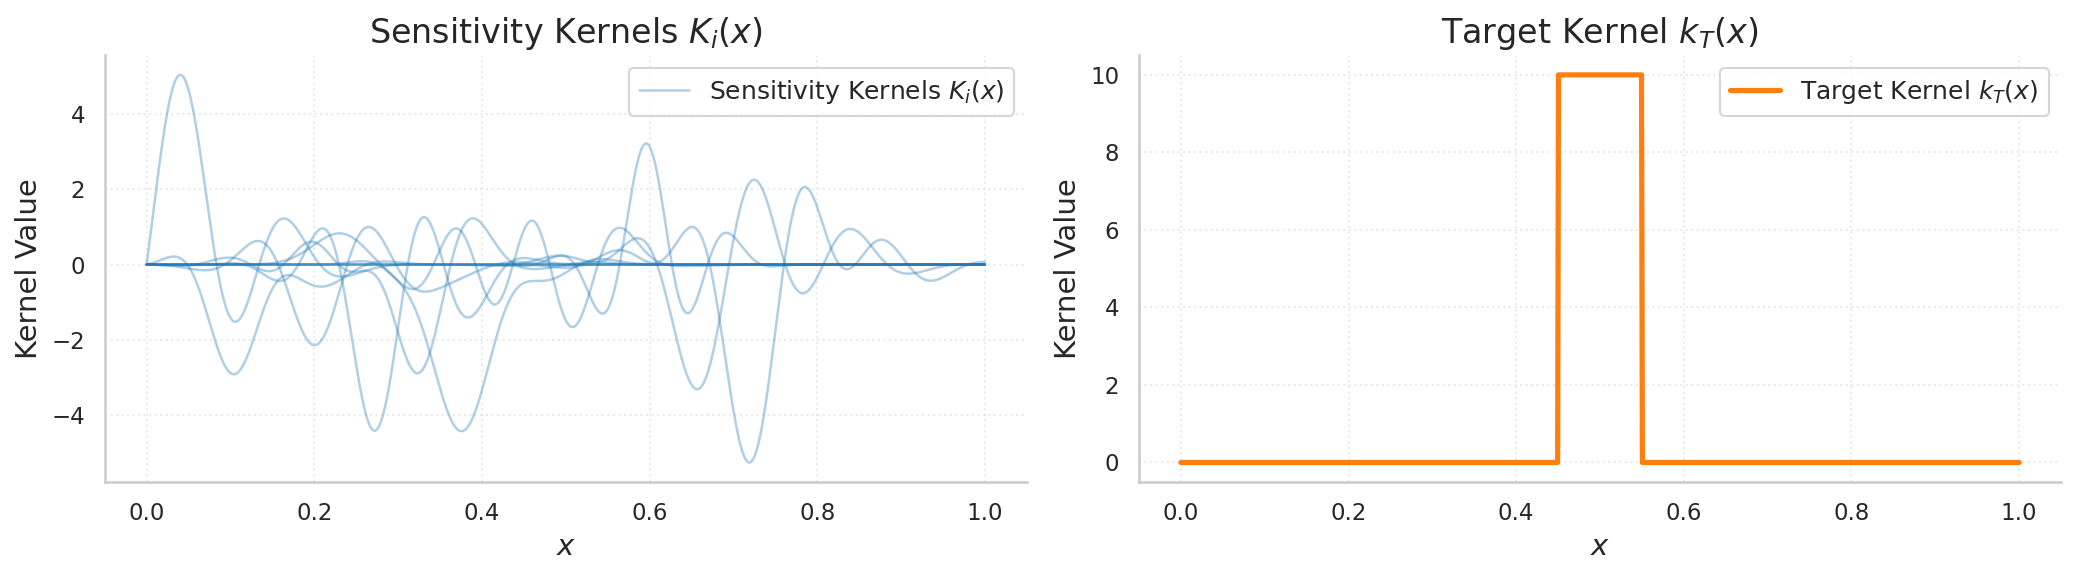

In [3]:
cfg = IntegrationConfig(method='simpson', n_points=400)

modes_provider = NormalModesProvider(M, random_state=1, gaussian_width_percent_range=(5, 10))
G = SOLAOperator(M, D, kernels=modes_provider, integration_config=cfg)

target = BoxCarFunctionProvider(M).get_function_by_parameters(
    {'center': 0.5, 'width': 0.1, 'normalize': True}
)
T = SOLAOperator(M, P, kernels=[target], integration_config=cfg)

x = function_domain.uniform_mesh(1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=150)

# ── Sensitivity kernels ────────────────────────────────────────────────────
ax = axes[0]
for i in range(N_d):
    ax.plot(
        x, G.get_kernel(i).evaluate(x),
        color='tab:blue', alpha=0.35, linewidth=1.2,
        label='Sensitivity Kernels $K_i(x)$' if i == 0 else '',
    )
ax.set_title(r'Sensitivity Kernels $K_i(x)$', fontsize=16)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel('Kernel Value', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax)

# ── Target kernel ──────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x, target.evaluate(x), color='tab:orange', linewidth=2.5,
         label=r'Target Kernel $k_T(x)$')
ax2.set_title(r'Target Kernel $k_T(x)$', fontsize=16)
ax2.set_xlabel(r'$x$', fontsize=14)
ax2.set_ylabel('Kernel Value', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

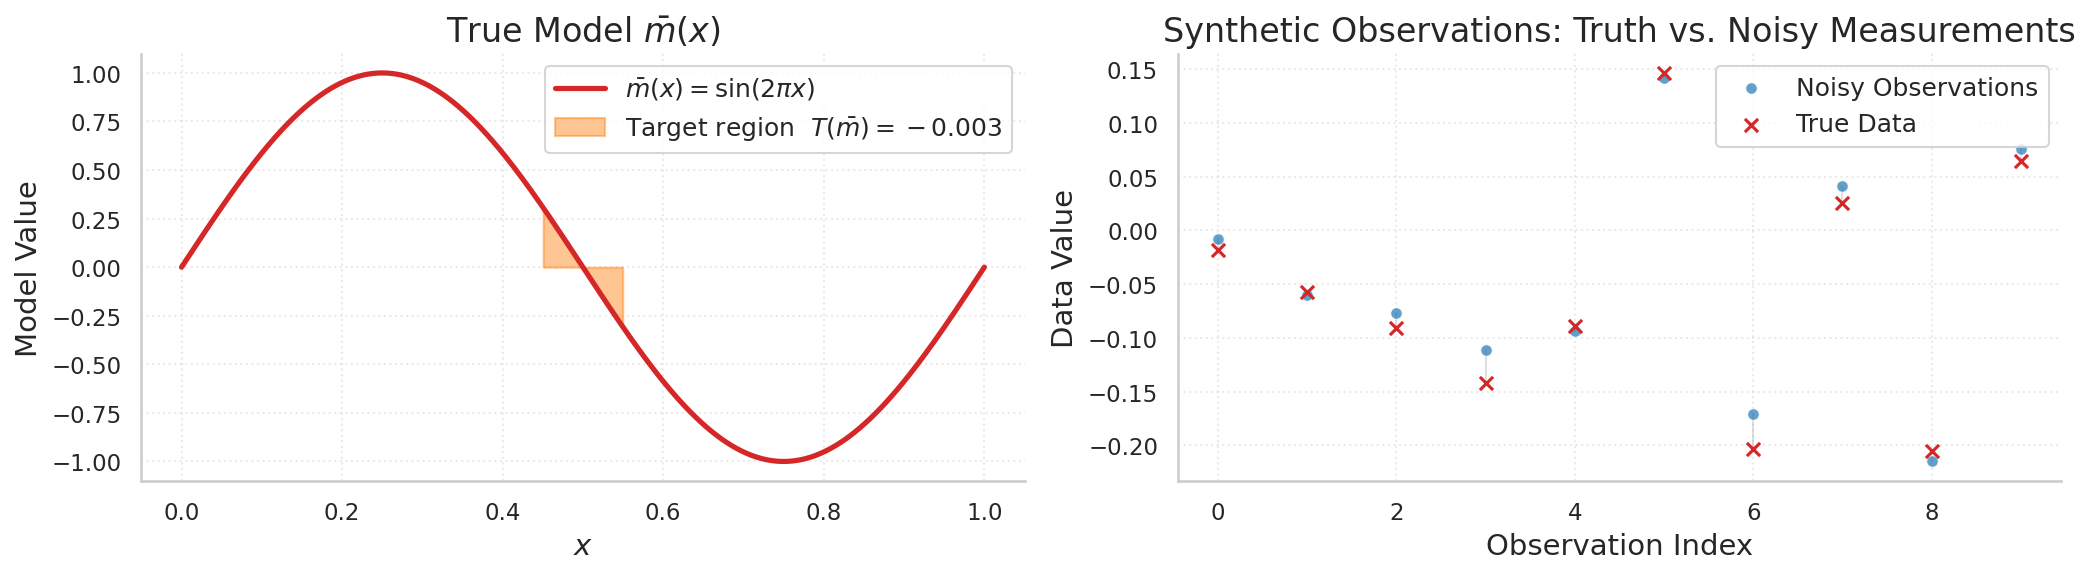

True property  T(m̄)      = -0.0026
Signal-to-noise ratio     = 10.0


In [4]:
np.random.seed(42)
m_bar = Function(M, evaluate_callable=lambda x: np.sin(2 * np.pi * x))

d_bar = G(m_bar)
noise_level = 0.1 * np.max(np.abs(d_bar))
noise = noise_level * np.random.standard_normal(d_bar.shape)
d_tilde = d_bar + noise

C_D = MatrixLinearOperator(D, D, noise_level**2 * np.eye(N_d))

p_true = float(T(m_bar)[0])   # scalar property value

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=150)

# ── Left: true model with shaded target region ─────────────────────────────
ax = axes[0]
ax.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label=r'$\bar{m}(x) = \sin(2\pi x)$')
ax.fill_between(
    x, 0, m_bar.evaluate(x),
    where=((x >= 0.45) & (x <= 0.55)),
    alpha=0.45, color='tab:orange',
    label=fr'Target region  $T(\bar{{m}}) = {p_true:.3f}$',
)
ax.set_title(r'True Model $\bar{m}(x)$', fontsize=16)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel('Model Value', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax)

# ── Right: observations ────────────────────────────────────────────────────
ax2 = axes[1]
data_indices = np.arange(N_d)
for i in range(N_d):
    ax2.plot([i, i], [d_bar[i], d_tilde[i]], color='gray', alpha=0.3, linewidth=0.8)
ax2.scatter(
    data_indices, d_tilde,
    color='tab:blue', alpha=0.7, s=30,
    edgecolors='white', linewidths=0.5,
    label='Noisy Observations', zorder=5,
)
ax2.scatter(
    data_indices, d_bar,
    color='tab:red', marker='x', s=40, linewidths=1.5,
    label='True Data', zorder=5,
)
ax2.set_xlabel('Observation Index', fontsize=14)
ax2.set_ylabel('Data Value', fontsize=14)
ax2.set_title('Synthetic Observations: Truth vs. Noisy Measurements', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print(f"True property  T(m̄)      = {p_true:.4f}")
print(f"Signal-to-noise ratio     = {np.max(np.abs(d_bar)) / noise_level:.1f}")

In [5]:
solver = CholeskySolver(parallel=True, n_jobs=12)
m_tilde = (G.adjoint @ solver(G @ G.adjoint + C_D))(d_tilde)

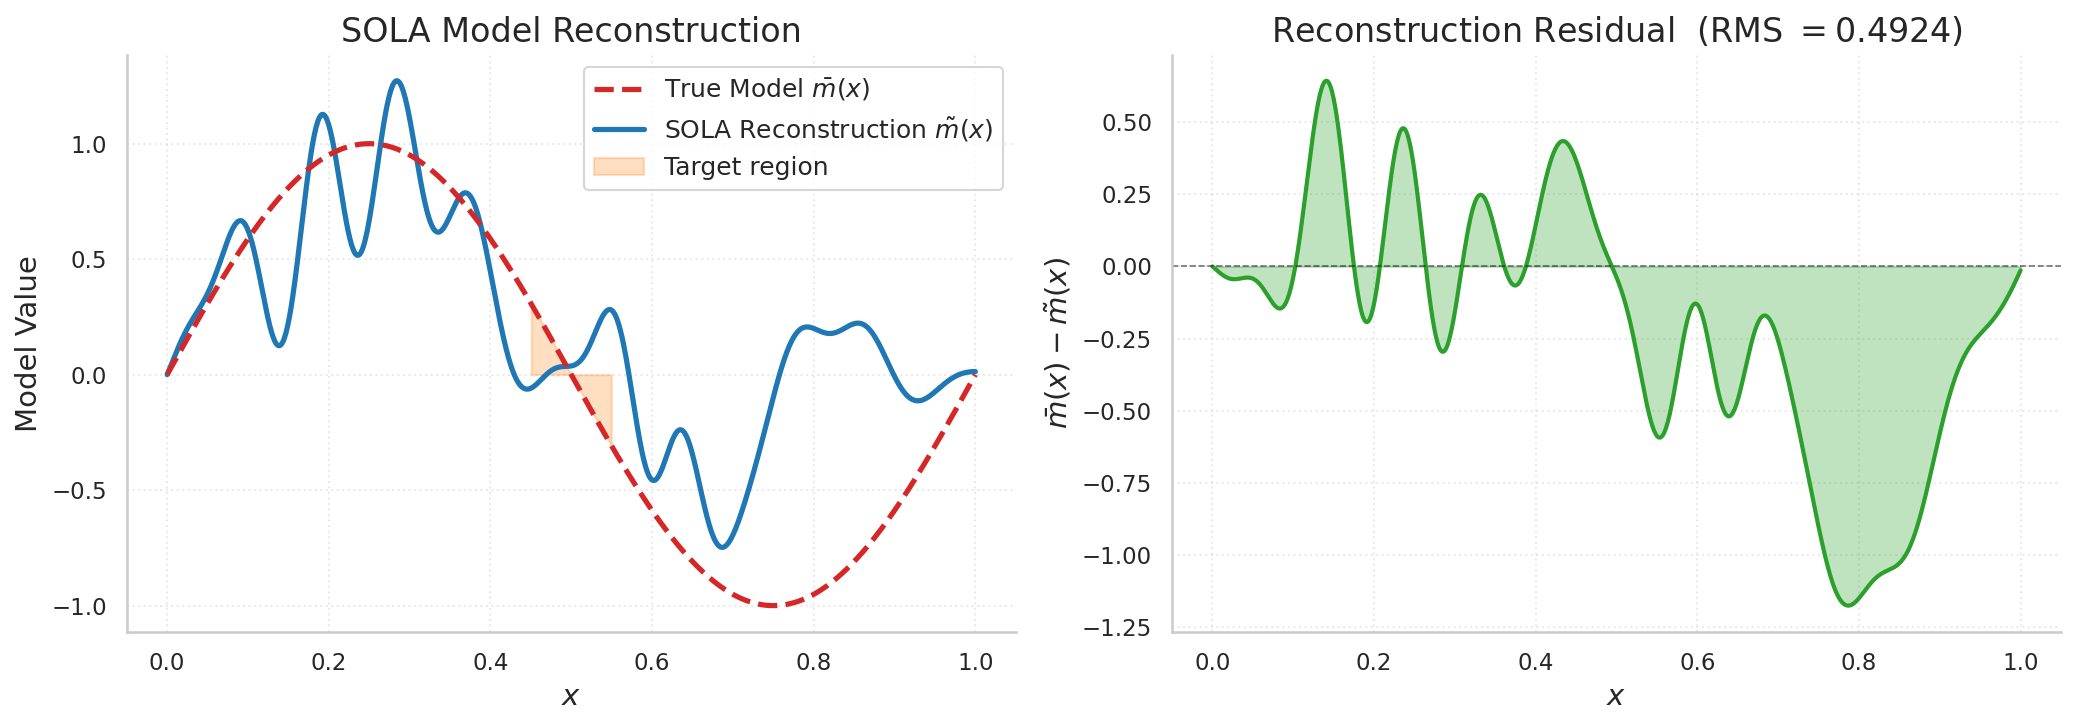

RMS reconstruction error  : 0.4924
Relative error            : 69.7%
Data misfit (prior=zero)  : 0.0004


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ── Left: model comparison ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, m_bar.evaluate(x), color='tab:red', linestyle='--', linewidth=2.5,
        label=r'True Model $\bar{m}(x)$', zorder=10)
ax.plot(x, m_tilde.evaluate(x), color='tab:blue', linewidth=2.5,
        label=r'SOLA Reconstruction $\tilde{m}(x)$', zorder=5)
ax.fill_between(
    x, 0, m_bar.evaluate(x),
    where=((x >= 0.45) & (x <= 0.55)),
    alpha=0.25, color='tab:orange', label='Target region',
)
ax.set_title(r'SOLA Model Reconstruction', fontsize=16)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel('Model Value', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax)

# ── Right: reconstruction residual ────────────────────────────────────────
ax2 = axes[1]
residual = m_bar.evaluate(x) - m_tilde.evaluate(x)
rms = np.sqrt(np.mean(residual**2))
ax2.plot(x, residual, color='tab:green', linewidth=2.0)
ax2.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.6)
ax2.fill_between(x, residual, 0, alpha=0.3, color='tab:green')
ax2.set_title(fr'Reconstruction Residual  (RMS $= {rms:.4f}$)', fontsize=16)
ax2.set_xlabel(r'$x$', fontsize=14)
ax2.set_ylabel(r'$\bar{m}(x) - \tilde{m}(x)$', fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print(f"RMS reconstruction error  : {rms:.4f}")
print(f"Relative error            : {100 * rms / np.std(m_bar.evaluate(x)):.1f}%")
print(f"Data misfit (prior=zero)  : {np.linalg.norm(d_tilde - G(m_tilde)):.4f}")

In [7]:
from pygeoinf.backus_gilbert import DualMasterCostFunction
from pygeoinf import BallSupportFunction, SubgradientDescent

# ── Prior and noise sets ───────────────────────────────────────────────────
r_M = 2.0          # prior ball radius in L²[0,1]
r_V = noise_level  # data-noise ball radius ≈ measured noise level

model_constraint   = BallSupportFunction(M, center=M.zero, radius=r_M)
data_error_support = BallSupportFunction(D, center=D.zero, radius=r_V)

# ── Upper bound: q = +e₁  →  p₊ = h_U(+e₁) ──────────────────────────────
q_up = P.from_components(np.array([1.0]))
cost_fn = DualMasterCostFunction(
    D, P, M, G, T, model_constraint, data_error_support, d_tilde, q_up
)

result_up = SubgradientDescent(
    cost_fn,
    step_size         = 1e-2,
    max_iterations    = 1500,
    store_iterates    = True,
    stagnation_window = 150,
).solve(D.random())
h_upper = result_up.f_best

# ── Lower bound: q = -e₁  →  p₋ = -h_U(-e₁) ─────────────────────────────
q_dn = P.from_components(np.array([-1.0]))
cost_fn.set_direction(q_dn)

result_dn = SubgradientDescent(
    cost_fn,
    step_size         = 1e-2,
    max_iterations    = 1500,
    store_iterates    = True,
    stagnation_window = 150,
).solve(D.random())
h_lower = -result_dn.f_best

# ── Results ────────────────────────────────────────────────────────────────
inside = h_lower <= p_true <= h_upper

print(f"Prior ball radius r_M     = {r_M}")
print(f"Noise ball radius r_V     = {r_V:.4f}")
print()
print(f"h_U(+e₁) [upper]          = {h_upper:.4f}")
print(f"h_U(-e₁) [→ lower]        = {result_dn.f_best:.4f}  →  p₋ = {h_lower:.4f}")
print()
print(f"Admissible interval  U    = [{h_lower:.4f},  {h_upper:.4f}]")
print(f"True property  T(m̄)       = {p_true:.4f}")
print(f"T(m̄) ∈ U ?                 {'YES ✓' if inside else 'NO ✗'}")

Prior ball radius r_M     = 2.0
Noise ball radius r_V     = 0.0205

h_U(+e₁) [upper]          = 6.0472
h_U(-e₁) [→ lower]        = 5.8764  →  p₋ = -5.8764

Admissible interval  U    = [-5.8764,  6.0472]
True property  T(m̄)       = -0.0026
T(m̄) ∈ U ?                 YES ✓


In [8]:
print("=" * 55)
print("FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"Admissible interval   U = [{h_lower:.4f},  {h_upper:.4f}]")
print(f"Interval width            {h_upper - h_lower:.4f}")
print(f"True property  T(m̄)     = {p_true:.4f}")
print(f"T(m̄) ∈ U ?                {'YES ✓' if h_lower <= p_true <= h_upper else 'NO ✗'}")
print()
print(f"Upper bound converged  : {result_up.converged}  ({result_up.num_iterations} iters)")
print(f"Lower bound converged  : {result_dn.converged}  ({result_dn.num_iterations} iters)")
print("=" * 55)

FINAL RESULTS SUMMARY
Admissible interval   U = [-5.8764,  6.0472]
Interval width            11.9235
True property  T(m̄)     = -0.0026
T(m̄) ∈ U ?                YES ✓

Upper bound converged  : False  (1500 iters)
Lower bound converged  : False  (1500 iters)


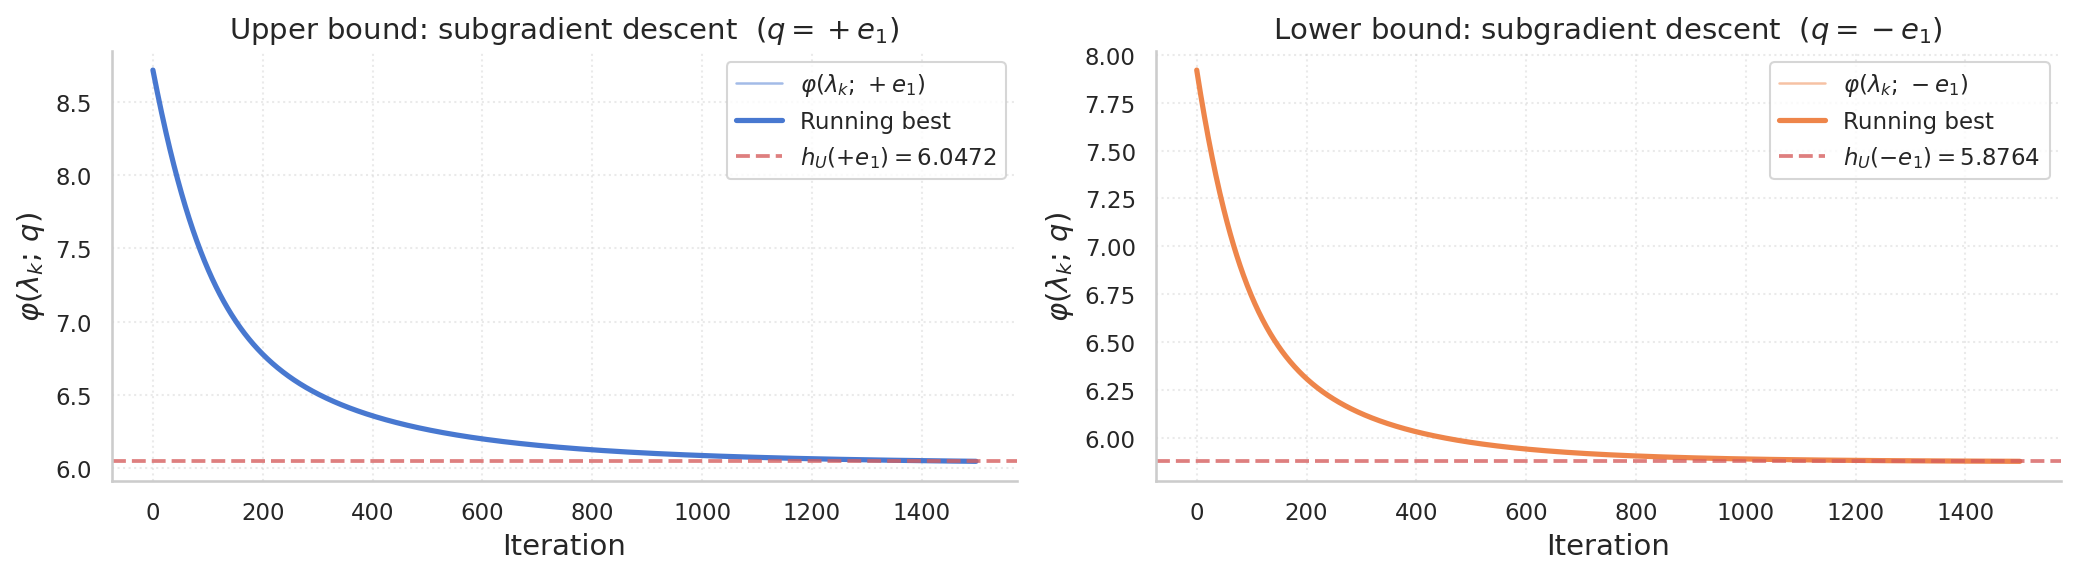

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=150)

# ── Upper bound convergence ────────────────────────────────────────────────
ax = axes[0]
fvals_up = result_up.function_values
ax.plot(fvals_up, color='C0', lw=1.2, alpha=0.5, label=r'$\varphi(\lambda_k;\, +e_1)$')
ax.plot(np.minimum.accumulate(fvals_up), color='C0', lw=2.5, label='Running best')
ax.axhline(h_upper, color='C3', ls='--', lw=1.8, alpha=0.8,
           label=fr'$h_{{U}}(+e_1) = {h_upper:.4f}$')
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel(r'$\varphi(\lambda_k;\, q)$', fontsize=14)
ax.set_title(r'Upper bound: subgradient descent  ($q = +e_1$)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax)

# ── Lower bound convergence ────────────────────────────────────────────────
ax2 = axes[1]
fvals_dn = result_dn.function_values
ax2.plot(fvals_dn, color='C1', lw=1.2, alpha=0.5, label=r'$\varphi(\lambda_k;\, -e_1)$')
ax2.plot(np.minimum.accumulate(fvals_dn), color='C1', lw=2.5, label='Running best')
ax2.axhline(result_dn.f_best, color='C3', ls='--', lw=1.8, alpha=0.8,
            label=fr'$h_{{U}}(-e_1) = {result_dn.f_best:.4f}$')
ax2.set_xlabel('Iteration', fontsize=14)
ax2.set_ylabel(r'$\varphi(\lambda_k;\, q)$', fontsize=14)
ax2.set_title(r'Lower bound: subgradient descent  ($q = -e_1$)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode


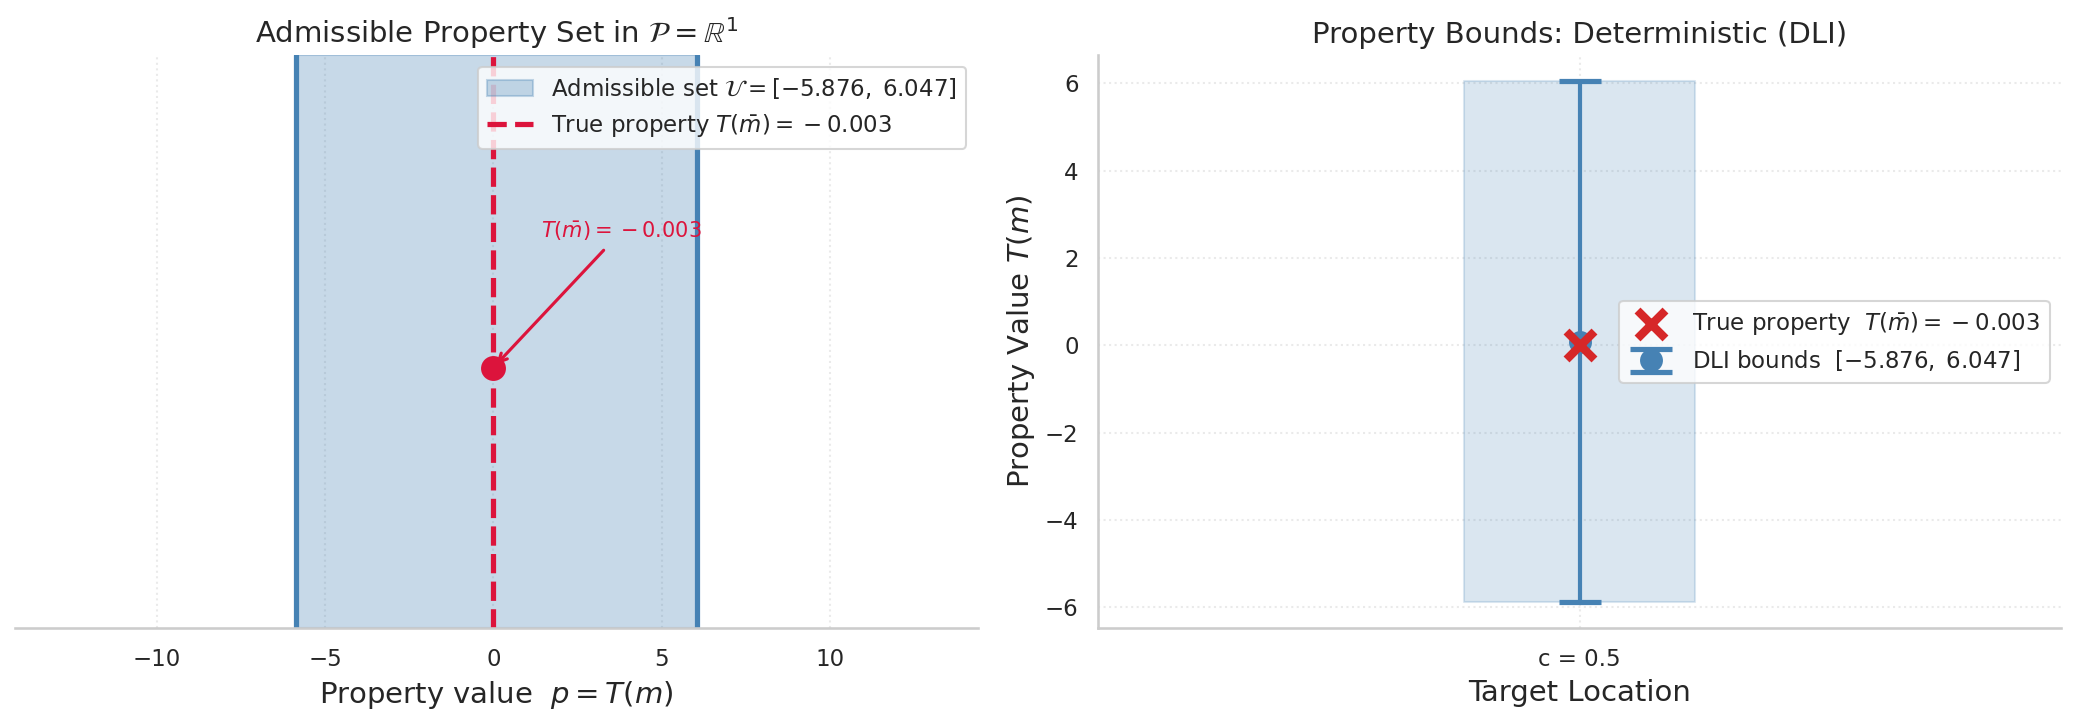

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ── Left: admissible interval on the number line ──────────────────────────
ax = axes[0]
margin = (h_upper - h_lower) * 0.7
xlim = (h_lower - margin, h_upper + margin)

ax.axvspan(h_lower, h_upper, alpha=0.30, color='steelblue',
           label=fr'Admissible set $\mathcal{{U}} = [{h_lower:.3f},\; {h_upper:.3f}]$')
ax.axvline(h_lower, color='steelblue', lw=2.5)
ax.axvline(h_upper, color='steelblue', lw=2.5)
ax.axvline(p_true, color='crimson', lw=2.5, ls='--',
           label=fr'True property $T(\bar{{m}}) = {p_true:.3f}$')
ax.scatter([p_true], [0], color='crimson', s=120, zorder=5)
ax.annotate(
    fr'$T(\bar{{m}}) = {p_true:.3f}$',
    xy=(p_true, 0), xytext=(p_true + 0.05 * (xlim[1] - xlim[0]), 0.25),
    fontsize=10, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
)
ax.set_xlim(xlim)
ax.set_ylim(-0.5, 0.6)
ax.set_yticks([])
ax.set_xlabel(r'Property value  $p = T(m)$', fontsize=14)
ax.set_title(r'Admissible Property Set in $\mathcal{P} = \mathbb{R}^1$', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax, left=True)

# ── Right: DLI bounds as error-bar (mirrors PLI ±2σ plot) ─────────────────
ax2 = axes[1]
mid   = (h_upper + h_lower) / 2
half  = (h_upper - h_lower) / 2

# DLI admissible interval (blue error-bar centered on interval mid-point)
ax2.errorbar(
    [0.5], [mid], yerr=[[half], [half]],
    fmt='o', color='steelblue', ms=10,
    capsize=10, capthick=2.5, lw=2,
    label=fr'DLI bounds  $[{h_lower:.3f},\; {h_upper:.3f}]$',
)
ax2.fill_between([0.38, 0.62], [mid - half, mid - half], [mid + half, mid + half],
                 alpha=0.20, color='steelblue')

# True property (red cross, same convention as PLI)
ax2.scatter([0.5], [p_true], color='tab:red', marker='x', s=180,
            linewidths=4, zorder=10,
            label=fr'True property  $T(\bar{{m}}) = {p_true:.3f}$')

ax2.set_xlim(0.0, 1.0)
ax2.set_xticks([0.5])
ax2.set_xticklabels(['c = 0.5'])
ax2.set_xlabel('Target Location', fontsize=14)
ax2.set_ylabel(r'Property Value $T(m)$', fontsize=14)
ax2.set_title('Property Bounds: Deterministic (DLI)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()